In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

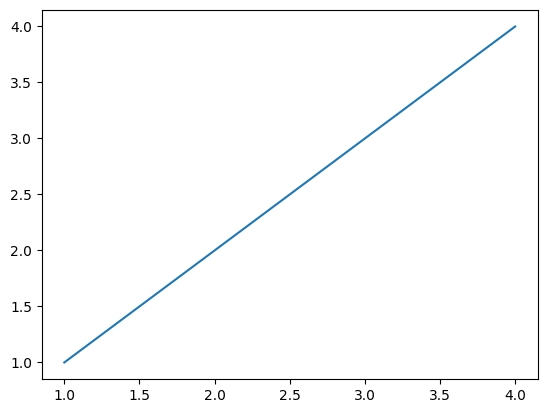

In [ ]:
# Simple Example

x = [1, 2, 3, 4]
y = [1, 2, 3, 4]

plt.plot(x, y)

plt.show() #removes jargon from top of the plot

**Plotting Job Posting Dates**

In [ ]:
df.job_posted_date.head()

,job_posted_date
0,2023-06-16 13:44:15
1,2023-01-14 13:18:07
2,2023-10-10 13:14:55
3,2023-07-04 13:01:41
4,2023-08-07 14:29:36


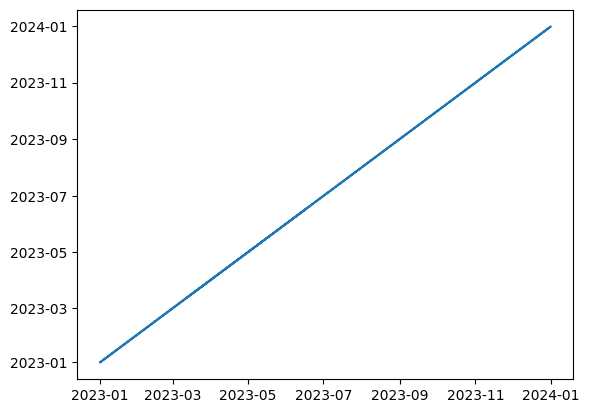

In [ ]:
plt.plot(df.job_posted_date, df.job_posted_date)

In [ ]:
date_counts = df.job_posted_date.value_counts()

# need to sort the dates before plotting
date_counts = date_counts.sort_index()



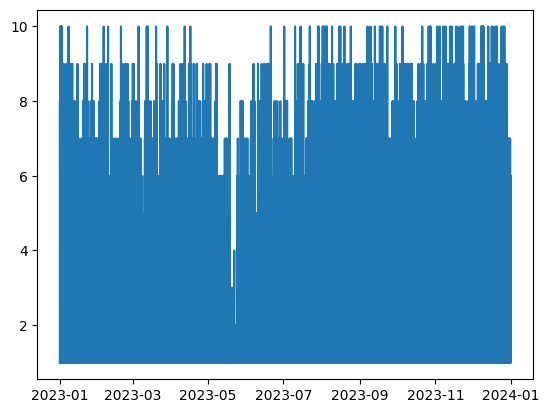

In [ ]:
# plot is still a mess because we need to agg by either day or month
plt.plot(date_counts.index, date_counts)

In [ ]:
# We first need to create a month column in the df
df['job_posted_month'] = df['job_posted_date'].dt.month

#check to make sure month column was added
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None,6
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",10
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete...",3
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi...",3
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}",3
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",3


In [ ]:
# next we need to create the monthly counts
monthly_counts = df.job_posted_month.value_counts()

# sort by month number
monthly_counts = monthly_counts.sort_index()

monthly_counts

,count
job_posted_month,
1,91822
2,64578
3,64084
4,62919
5,52104
6,61572
7,63777
8,75162
9,62359


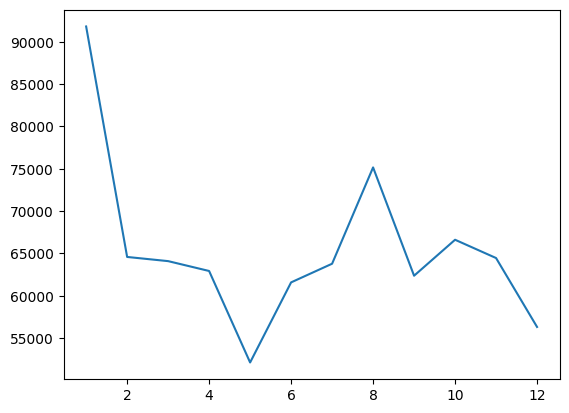

In [ ]:
plt.plot(monthly_counts.index, monthly_counts)

**BAR CHART - COUNTS OF JOB POSTINGS**

In [ ]:
# create a variable called job counts
job_counts = df.job_title_short.value_counts()

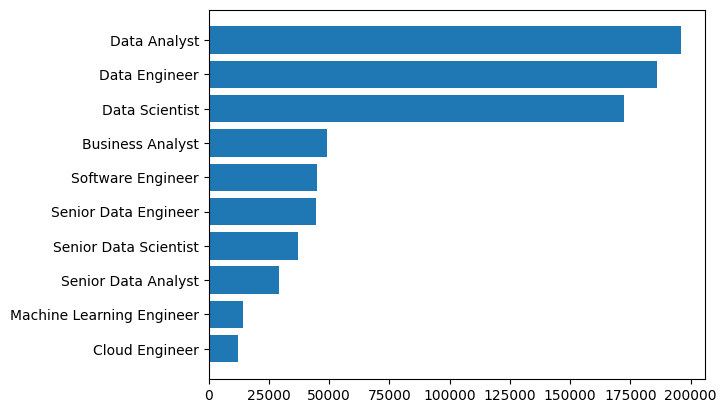

In [ ]:
# fix the sorting
job_counts = job_counts.sort_values(ascending = True)

# plotting job titles and counts
plt.barh(job_counts.index,job_counts)

plt.show()

**LABELING**

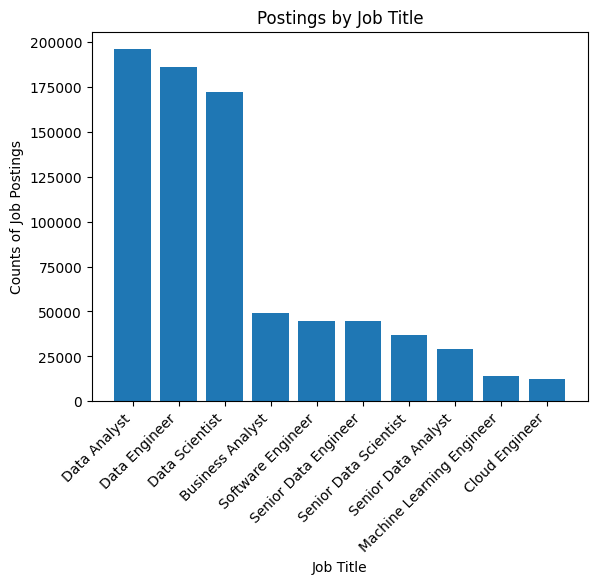

In [ ]:
# fix the sorting
job_counts = job_counts.sort_values(ascending = False)

plt.bar(job_counts.index, job_counts)
plt.title('Postings by Job Title')
plt.ylabel('Counts of Job Postings')
plt.xticks(rotation =45, ha='right')
plt.xlabel('Job Title')
plt.show()

**PANDAS PLOTTING**

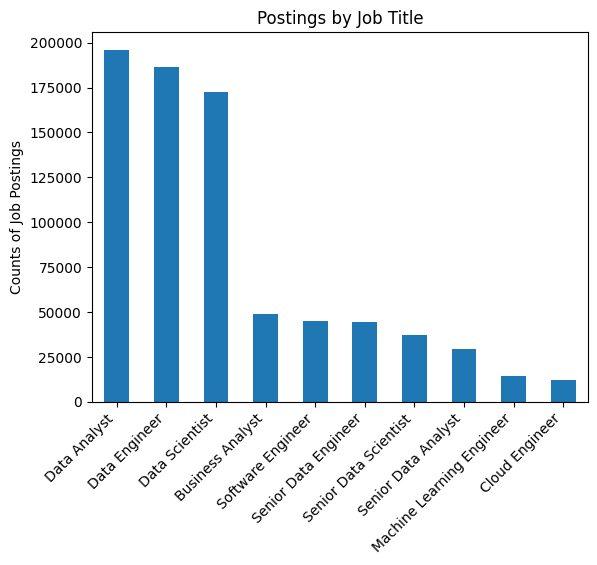

In [ ]:
# Pandas provides a much easier way to plot

# bar plot example
job_counts.plot(kind= 'bar')
plt.title('Postings by Job Title')
plt.ylabel('Counts of Job Postings')
plt.xticks(rotation =45, ha='right')
plt.xlabel('')
plt.show()

# line chart example
# job_counts.plot(kind= 'line')

<Axes: xlabel='job_posted_date'>

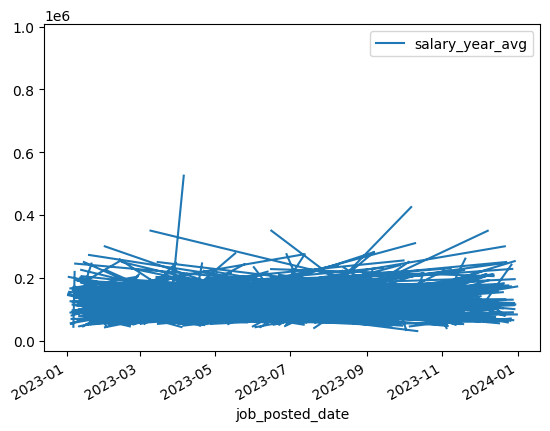

In [ ]:
df.plot(x = 'job_posted_date', y = 'salary_year_avg', kind = 'line')

**EXERCISE**

In [ ]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

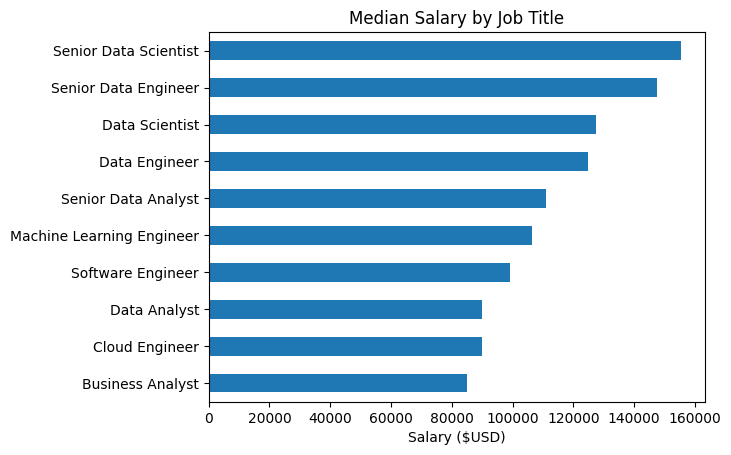

In [ ]:
job_salary.plot(kind='barh')
plt.xlabel('Salary ($USD)')
plt.ylabel('')
plt.title('Median Salary by Job Title')
plt.show()